# Cadenas de Markov: descomposición canónica

Sea $P$ la matriz de transición de una cadena de Markov sobre el espacio de
estados $\{a, b, c, d, e, f, g\}$. En esta Notebook:

1. Se define $P$ y se dibuja su diagrama de transiciones.
2. Se determina si la cadena posee distribución límite.
3. Se obtiene la **descomposición canónica**, se calcula
   $\displaystyle\lim_{n\to\infty}P^{n}$ y se compara con las distribuciones
   límite de cada submatriz cerrada.
4. Se implementa una función general que halla la descomposición canónica
   de cualquier matriz estocástica.

In [ ]:
# Bibliotecas estándar
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Impresión legible de matrices con flotantes
np.set_printoptions(precision=4, suppress=True, linewidth=110)

## 1. Matriz $P$ y diagrama de transiciones

$$
P=\begin{pmatrix}
1/4 & 0 & 0 & 0 & 0 & 0 & 3/4\\
1/8 & 1/8 & 1/4 & 0 & 1/4 & 1/8 & 1/8\\
0 & 0 & 2/5 & 1/5 & 2/5 & 0 & 0\\
0 & 0 & 1/2 & 1/2 & 0 & 0 & 0\\
0 & 0 & 0 & 1/2 & 1/2 & 0 & 0\\
0 & 1/5 & 0 & 1/5 & 1/5 & 1/5 & 1/5\\
4/5 & 0 & 0 & 0 & 0 & 0 & 1/5
\end{pmatrix}
$$

In [ ]:
# Definición de la matriz de transición
import numpy as np
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
print("\nMatriz P:")
print(P)


Matriz P:
[[0.25  0.    0.    0.    0.    0.    0.75 ]
 [0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.    0.2   0.    0.2   0.2   0.2   0.2  ]
 [0.8   0.    0.    0.    0.    0.    0.2  ]]


### Diagrama de transiciones

Cada arista del grafo corresponde a una entrada positiva de $P$ y se
etiqueta con la probabilidad de transición.

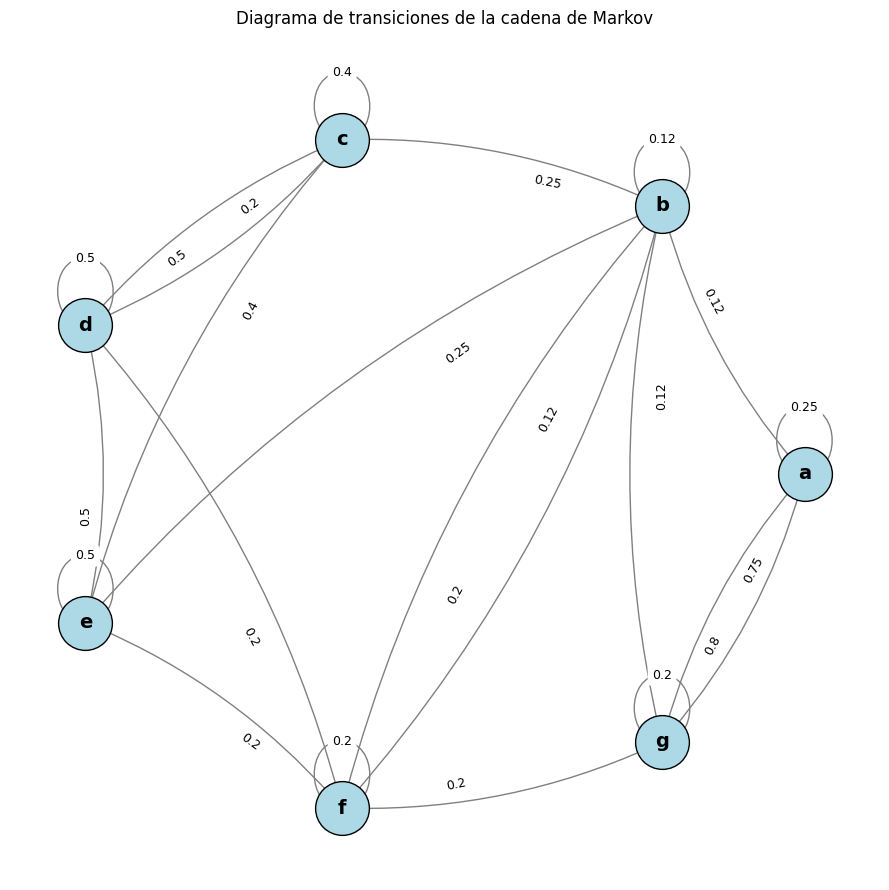

In [ ]:
# Construcción del grafo dirigido inducido por P
G = nx.DiGraph()
G.add_nodes_from(estados)
for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        if P[i, j] > 0:
            G.add_edge(origen, destino, weight=P[i, j])

# Disposición circular
pos = nx.circular_layout(G)

plt.figure(figsize=(9, 9))
nx.draw_networkx_nodes(G, pos,
                       node_color='lightblue',
                       node_size=1500,
                       edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# las aristas para que las parejas bidireccionales sean distinguibles
nx.draw_networkx_edges(G, pos,
                       arrows=True,
                       arrowsize=20,
                       edge_color='gray',
                       connectionstyle='arc3,rad=0.12')

# Etiquetas con la probabilidad de transición
edge_labels = {(u, v): f"{d['weight']:.2g}"
               for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=9,
                             label_pos=0.35)

plt.title("Diagrama de transiciones de la cadena de Markov")
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. ¿Existe distribución límite?

Una cadena de Markov tiene **una única** distribución límite si y sólo si es
**irreducible y aperiódica**. Identificamos las clases comunicantes
(componentes fuertemente conexas del grafo) y, para cada una, decidimos si
es **cerrada** (recurrente) o **transitoria**.

> Una clase $C$ es cerrada si para todo $i\in C$ y todo $j\notin C$ se tiene
> $P_{ij}=0$; equivalentemente, no hay aristas que salgan de $C$.

In [17]:
# Componentes fuertemente conexas (clases comunicantes)
sccs = [sorted(c) for c in nx.strongly_connected_components(G)]

print("Clases comunicantes:")
for c in sccs:
    print("  ", c)

# Clasificación cerrada / transitoria
cerradas, transitorias = [], []
for c in sccs:
    cset = set(c)
    sale_de_la_clase = any(
        P[estados.index(i), estados.index(j)] > 0
        for i in c for j in estados if j not in cset
    )
    (transitorias if sale_de_la_clase else cerradas).append(c)

print("\nClases cerradas (recurrentes):", cerradas)
print("Clases transitorias:", transitorias)

Clases comunicantes:
   ['a', 'g']
   ['c', 'd', 'e']
   ['b', 'f']

Clases cerradas (recurrentes): [['a', 'g'], ['c', 'd', 'e']]
Clases transitorias: [['b', 'f']]


La cadena tiene **dos clases recurrentes**, $C_1=\{a,g\}$ y
$C_2=\{c,d,e\}$, y **una clase transitoria** $T=\{b,f\}$.

Como existe más de una clase recurrente, la cadena **no es irreducible** y
por lo tanto **no posee una única distribución límite**: el límite
$\lim_{n\to\infty}P^n$ existe (cada clase recurrente es aperiódica, como
verificamos a continuación), pero depende del estado inicial — la
distribución límite es una combinación convexa de las distribuciones
estacionarias de $C_1$ y $C_2$ con pesos iguales a las probabilidades de
absorción.

In [ ]:
# Aperiodicidad: condición suficiente sencilla — existe i en la clase
# tal que P[i, i] > 0  (autolazo => período 1).
print("Aperiodicidad de las clases recurrentes:")
for c in cerradas:
    diag = [P[estados.index(i), estados.index(i)] for i in c]
    aper = any(d > 0 for d in diag)
    print(f"  Clase {c}: P_ii = {diag} -> aperiódica: {aper}")

Aperiodicidad de las clases recurrentes:
  Clase ['a', 'g']: P_ii = [np.float64(0.25), np.float64(0.2)] -> aperiódica: True
  Clase ['c', 'd', 'e']: P_ii = [np.float64(0.4), np.float64(0.5), np.float64(0.5)] -> aperiódica: True


## 3. Descomposición canónica y límite de $P^n$

Reordenando los estados como $(a, g \mid c, d, e \mid b, f)$ se obtiene
$$
\widetilde P =
\begin{pmatrix}
P_1 & 0   & 0 \\
0   & P_2 & 0 \\
R_1 & R_2 & Q
\end{pmatrix},
$$
con $P_1$ la submatriz sobre $C_1=\{a,g\}$, $P_2$ la submatriz sobre
$C_2=\{c,d,e\}$, $Q$ la submatriz sobre los transitorios $T=\{b,f\}$ y
$R_1, R_2$ las transiciones $T\!\to\!C_1$, $T\!\to\!C_2$.

In [ ]:
# Construcción manual de la forma canónica
orden_canonico = ['a', 'g', 'c', 'd', 'e', 'b', 'f']
idx = [estados.index(s) for s in orden_canonico]

# Permutación simétrica: filas y columnas en el mismo orden
P_can = P[np.ix_(idx, idx)]

print("Estados en orden canónico:", orden_canonico)
print("\nMatriz canónica P~:")
print(P_can)

# Bloques
P1 = P_can[0:2, 0:2]   # C_1 = {a, g}
P2 = P_can[2:5, 2:5]   # C_2 = {c, d, e}
Q  = P_can[5:7, 5:7]   # T   = {b, f}
R1 = P_can[5:7, 0:2]   # T -> C_1
R2 = P_can[5:7, 2:5]   # T -> C_2

print("\nP1 (clase {a,g}):\n",     P1)
print("\nP2 (clase {c,d,e}):\n",   P2)
print("\nQ (transitorios {b,f}):\n", Q)
print("\nR1 ({b,f} -> {a,g}):\n",   R1)
print("\nR2 ({b,f} -> {c,d,e}):\n", R2)

Estados en orden canónico: ['a', 'g', 'c', 'd', 'e', 'b', 'f']

Matriz canónica P~:
[[0.25  0.75  0.    0.    0.    0.    0.   ]
 [0.8   0.2   0.    0.    0.    0.    0.   ]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.    0.2   0.    0.2   0.2   0.2   0.2  ]]

P1 (clase {a,g}):
 [[0.25 0.75]
 [0.8  0.2 ]]

P2 (clase {c,d,e}):
 [[0.4 0.2 0.4]
 [0.5 0.5 0. ]
 [0.  0.5 0.5]]

Q (transitorios {b,f}):
 [[0.125 0.125]
 [0.2   0.2  ]]

R1 ({b,f} -> {a,g}):
 [[0.125 0.125]
 [0.    0.2  ]]

R2 ({b,f} -> {c,d,e}):
 [[0.25 0.   0.25]
 [0.   0.2  0.2 ]]


### Distribuciones estacionarias de las clases recurrentes

Cada $C_k$ es irreducible y aperiódica, así que admite una única
distribución estacionaria $\pi^{(k)}$ que satisface
$\pi^{(k)} P_k = \pi^{(k)}$ y $\sum_i \pi^{(k)}_i = 1$.

Resolvemos el sistema lineal $\pi(P_k - I) = 0$ junto con la restricción de
normalización.

In [ ]:
def distribucion_estacionaria(P_sub):
    """
    Resuelve pi P = pi con sum(pi) = 1 mediante mínimos cuadrados.
    Equivalente a apilar (P - I)^T y un renglón de unos, y resolver
    el sistema sobredeterminado.
    """
    n = P_sub.shape[0]
    A = np.vstack([(P_sub - np.eye(n)).T, np.ones(n)])
    b = np.zeros(n + 1)
    b[-1] = 1
    pi, *_ = np.linalg.lstsq(A, b, rcond=None)
    return pi

pi1 = distribucion_estacionaria(P1)
pi2 = distribucion_estacionaria(P2)

print("pi^(1) sobre {a, g} =", pi1)
print("   exacto (16/31, 15/31) =", np.array([16/31, 15/31]))
print()
print("pi^(2) sobre {c, d, e} =", pi2)
print("   exacto (1/3, 2/5, 4/15)=", np.array([1/3, 2/5, 4/15]))

pi^(1) sobre {a, g} = [0.5161 0.4839]
   exacto (16/31, 15/31) = [0.5161 0.4839]

pi^(2) sobre {c, d, e} = [0.3333 0.4    0.2667]
   exacto (1/3, 2/5, 4/15)= [0.3333 0.4    0.2667]


### Cálculo de $\displaystyle\lim_{n\to\infty} P^n$

Como cada $P_k$ es irreducible y aperiódica:
$$
\lim_{n\to\infty} P_k^{\,n} = \mathbf 1\,\pi^{(k)}
\qquad(\text{todas las filas son } \pi^{(k)}).
$$

Para los estados transitorios definimos la **matriz fundamental**
$N=(I-Q)^{-1}$ y, para cada clase cerrada $C_k$, el vector de
**probabilidades de absorción**
$$
A_k \;=\; N\,R_k\,\mathbf 1 \;\in\;\mathbb R^{|T|}.
$$
La fila correspondiente a un estado transitorio $i\in T$ converge a
$$
\big(A_1[i]\,\pi^{(1)}\,,\ A_2[i]\,\pi^{(2)}\,,\ \mathbf 0\big).
$$

In [ ]:
# Matriz fundamental N = (I - Q)^{-1}
m = Q.shape[0]
N = np.linalg.inv(np.eye(m) - Q)
print("Matriz fundamental N = (I - Q)^(-1):")
print(N)

# Probabilidades de absorción en cada estado de cada clase cerrada
B1 = N @ R1
B2 = N @ R2

# Probabilidad TOTAL de absorción en cada clase
A1 = B1.sum(axis=1)
A2 = B2.sum(axis=1)

print("\nProbabilidad de absorción desde {b, f} en {a, g}    :", A1)
print("Probabilidad de absorción desde {b, f} en {c, d, e} :", A2)
print("Suma (debe ser 1):", A1 + A2)

Matriz fundamental N = (I - Q)^(-1):
[[1.1852 0.1852]
 [0.2963 1.2963]]

Probabilidad de absorción desde {b, f} en {a, g}    : [0.3333 0.3333]
Probabilidad de absorción desde {b, f} en {c, d, e} : [0.6667 0.6667]
Suma (debe ser 1): [1. 1.]


In [ ]:
# Construcción analítica del límite de P^n en la base canónica
n_total = len(orden_canonico)
P_inf = np.zeros((n_total, n_total))

# Filas correspondientes a C_1 = {a, g}
P_inf[0:2, 0:2] = np.tile(pi1, (2, 1))
# Filas correspondientes a C_2 = {c, d, e}
P_inf[2:5, 2:5] = np.tile(pi2, (3, 1))
# Filas correspondientes a los transitorios {b, f}
P_inf[5:7, 0:2] = np.outer(A1, pi1)
P_inf[5:7, 2:5] = np.outer(A2, pi2)
# El bloque Q^n -> 0 queda en cero (ya inicializado)

print("Limite analitico de P^n (en orden canonico):")
print(P_inf)

# Comparación con la potencia numérica
P_can_pow = np.linalg.matrix_power(P_can, 1000)
print("\nP_can^1000 (verificacion numerica):")
print(P_can_pow)

print("\nMaxima diferencia |analitico - numerico| =",
      np.max(np.abs(P_inf - P_can_pow)))

Limite analitico de P^n (en orden canonico):
[[0.5161 0.4839 0.     0.     0.     0.     0.    ]
 [0.5161 0.4839 0.     0.     0.     0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.1613 0.2222 0.2667 0.1778 0.     0.    ]
 [0.172  0.1613 0.2222 0.2667 0.1778 0.     0.    ]]

P_can^1000 (verificacion numerica):
[[0.5161 0.4839 0.     0.     0.     0.     0.    ]
 [0.5161 0.4839 0.     0.     0.     0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.1613 0.2222 0.2667 0.1778 0.     0.    ]
 [0.172  0.1613 0.2222 0.2667 0.1778 0.     0.    ]]

Maxima diferencia |analitico - numerico| = 3.885780586188048e-14


### Comparación con las distribuciones límite de las submatrices

Los bloques diagonales $P_1^{\,n}$ y $P_2^{\,n}$ convergen, individualmente,
a matrices cuyas filas son las distribuciones estacionarias $\pi^{(1)}$ y
$\pi^{(2)}$. Verificamos que esos bloques coinciden exactamente con los
bloques diagonales del $\lim P^n$ global sobre las clases cerradas

In [ ]:
P1_inf = np.linalg.matrix_power(P1, 1000)
P2_inf = np.linalg.matrix_power(P2, 1000)

print("lim P1^n  (submatriz {a, g}):")
print(P1_inf)
print("\nlim P2^n  (submatriz {c, d, e}):")
print(P2_inf)

print("\nBloque {a, g} de lim P^n:")
print(P_inf[0:2, 0:2])
print("Coincide con lim P1^n?",
      np.allclose(P_inf[0:2, 0:2], P1_inf))

print("\nBloque {c, d, e} de lim P^n:")
print(P_inf[2:5, 2:5])
print("Coincide con lim P2^n?",
      np.allclose(P_inf[2:5, 2:5], P2_inf))

lim P1^n  (submatriz {a, g}):
[[0.5161 0.4839]
 [0.5161 0.4839]]

lim P2^n  (submatriz {c, d, e}):
[[0.3333 0.4    0.2667]
 [0.3333 0.4    0.2667]
 [0.3333 0.4    0.2667]]

Bloque {a, g} de lim P^n:
[[0.5161 0.4839]
 [0.5161 0.4839]]
Coincide con lim P1^n? True

Bloque {c, d, e} de lim P^n:
[[0.3333 0.4    0.2667]
 [0.3333 0.4    0.2667]
 [0.3333 0.4    0.2667]]
Coincide con lim P2^n? True


## 4. Algoritmo general de descomposición canónica

La función `descomposicion_canonica` recibe una matriz estocástica $P$ y
(opcionalmente) los nombres de los estados, y devuelve la matriz reordenada
junto con la lista de clases cerradas, los estados transitorios y los
bloques $P_k$, $Q$, $R_k$.

**Pasos:**

1. Construir el grafo dirigido inducido por las entradas positivas de $P$.
2. Calcular sus componentes fuertemente conexas (clases comunicantes).
3. Marcar como **cerrada** toda clase de la que no sale ninguna arista hacia
   otra clase; las restantes son **transitorias**.
4. Construir el orden $(\text{clases cerradas},\ \text{transitorios})$ y
   permutar $P$ simétricamente.

In [ ]:
def descomposicion_canonica(P, estados=None):
    """
    Descomposicion canonica de una cadena de Markov con matriz P.

    Parametros
    ----------
    P : np.ndarray (n, n)
        Matriz de transicion estocastica (filas suman 1).
    estados : list, opcional
        Nombres de los estados. Por defecto se usan 0, 1, ..., n-1.

    Devuelve
    -------
    P_canonica : np.ndarray
        Matriz P reordenada en forma canonica.
    estados_canonicos : list
        Nombres de los estados en el nuevo orden.
    cerradas : list[list]
        Clases cerradas (recurrentes), por nombre de estado.
    transitorios : list
        Estados transitorios, por nombre de estado.
    bloques : dict
        {'P_cerradas': [P_1, P_2, ...],
         'Q'         : Q,
         'R_cerradas': [R_1, R_2, ...]}
    """
    n = P.shape[0]
    if estados is None:
        estados = list(range(n))

    # 1. Grafo dirigido inducido por las entradas positivas de P
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(i, j)

    # 2. Componentes fuertemente conexas (clases comunicantes)
    sccs = [sorted(c) for c in nx.strongly_connected_components(G)]

    # 3. Clasificacion: cerradas (sin aristas salientes) vs transitorias
    cerradas_idx, transitorias_idx = [], []
    for c in sccs:
        cset = set(c)
        sale = any(P[i, j] > 0
                   for i in c for j in range(n) if j not in cset)
        (transitorias_idx if sale else cerradas_idx).append(c)

    # 4. Orden canonico: primero cerradas, luego transitorios
    orden = []
    for c in cerradas_idx:
        orden.extend(c)
    transitorios_planos = [i for c in transitorias_idx for i in c]
    orden.extend(transitorios_planos)

    P_can = P[np.ix_(orden, orden)]
    estados_can = [estados[i] for i in orden]

    # Construccion de los bloques
    bloques = {'P_cerradas': [], 'R_cerradas': []}
    pos = 0
    for c in cerradas_idx:
        k = len(c)
        bloques['P_cerradas'].append(P_can[pos:pos + k, pos:pos + k])
        pos += k

    t = len(transitorios_planos)
    if t > 0:
        bloques['Q'] = P_can[-t:, -t:]
        ini = 0
        for c in cerradas_idx:
            k = len(c)
            bloques['R_cerradas'].append(P_can[-t:, ini:ini + k])
            ini += k
    else:
        bloques['Q'] = np.zeros((0, 0))

    cerradas_nombres     = [[estados[i] for i in c] for c in cerradas_idx]
    transitorios_nombres = [estados[i] for i in transitorios_planos]

    return P_can, estados_can, cerradas_nombres, transitorios_nombres, bloques

### Aplicación a la matriz $P$ del problema

In [ ]:
P_can_f, est_can_f, cerr_f, trans_f, bloques_f = \
    descomposicion_canonica(P, estados)

print("Estados en orden canonico:", est_can_f)
print("Clases cerradas:           ", cerr_f)
print("Estados transitorios:      ", trans_f)

print("\nMatriz canonica:")
print(P_can_f)

print("\nSubmatrices de las clases cerradas:")
for c, M in zip(cerr_f, bloques_f['P_cerradas']):
    print(f"  P_k para {c}:\n{M}\n")

print("Q (bloque transitorio):")
print(bloques_f['Q'])

for c, R in zip(cerr_f, bloques_f['R_cerradas']):
    print(f"\nR (transitorios -> {c}):\n{R}")

Estados en orden canonico: ['a', 'g', 'c', 'd', 'e', 'b', 'f']
Clases cerradas:            [['a', 'g'], ['c', 'd', 'e']]
Estados transitorios:       ['b', 'f']

Matriz canonica:
[[0.25  0.75  0.    0.    0.    0.    0.   ]
 [0.8   0.2   0.    0.    0.    0.    0.   ]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.    0.2   0.    0.2   0.2   0.2   0.2  ]]

Submatrices de las clases cerradas:
  P_k para ['a', 'g']:
[[0.25 0.75]
 [0.8  0.2 ]]

  P_k para ['c', 'd', 'e']:
[[0.4 0.2 0.4]
 [0.5 0.5 0. ]
 [0.  0.5 0.5]]

Q (bloque transitorio):
[[0.125 0.125]
 [0.2   0.2  ]]

R (transitorios -> ['a', 'g']):
[[0.125 0.125]
 [0.    0.2  ]]

R (transitorios -> ['c', 'd', 'e']):
[[0.25 0.   0.25]
 [0.   0.2  0.2 ]]


### Verificación con un segundo ejemplo

Cadena con dos estados absorbentes y dos transitorios:
$$
P_{\text{test}} =
\begin{pmatrix}
0.5 & 0.3 & 0.1 & 0.1\\
0.2 & 0.4 & 0.2 & 0.2\\
0   & 0   & 1   & 0  \\
0   & 0   & 0   & 1
\end{pmatrix}
$$
Aquí los estados $2$ y $3$ son absorbentes (cada uno forma una clase
cerrada de tamaño 1) y los estados $0$ y $1$ son transitorios.

In [ ]:
P_test = np.array([
    [0.5, 0.3, 0.1, 0.1],
    [0.2, 0.4, 0.2, 0.2],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0]
])

P_t_can, est_t, cerr_t, trans_t, bl_t = descomposicion_canonica(P_test)

print("Estados canonicos:", est_t)
print("Clases cerradas: ", cerr_t)
print("Transitorios:    ", trans_t)
print("\nMatriz canonica:")
print(P_t_can)
print("\nQ:")
print(bl_t['Q'])

Estados canonicos: [2, 3, 0, 1]
Clases cerradas:  [[2], [3]]
Transitorios:     [0, 1]

Matriz canonica:
[[1.  0.  0.  0. ]
 [0.  1.  0.  0. ]
 [0.1 0.1 0.5 0.3]
 [0.2 0.2 0.2 0.4]]

Q:
[[0.5 0.3]
 [0.2 0.4]]
